**Name: Rohan Sali**  
**Roll no. 24**  
**SL3 - Mini Project** 

Data Science Tweets Sentiment Classification  
Classify tweets into **positive** and **negative** sentiment labels using text classification.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import re
import string

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='muted')
print('Libraries loaded')

Libraries loaded


## 2. Load dataset

In [2]:
csv_path = 'tweets.csv'
try:
    df = pd.read_csv(csv_path)
    print('Dataset loaded from', csv_path)
except FileNotFoundError:
    raise FileNotFoundError(f"Could not find {csv_path}. Please ensure it's in the notebook working directory.")

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_13896\2594531264.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Dataset loaded from tweets.csv


,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,tweet,language,mentions,urls,photos,replies_count,retweets_count,likes_count,hashtags,cashtags,link,retweet,quote_url,video,thumbnail,near,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1406400408545804288,1406400396264943616,2021-06-20 05:26:01 IST,2021-06-20,05:26:01,530,1113747629282930688,ballouxfrancois,Prof Francois Balloux,NaN,What can be done? - Never blindly trust an ab...,en,[],[],[],6,10,144,[],[],https://twitter.com/BallouxFrancois/status/140...,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,1406390341176016897,1406390341176016897,2021-06-20 04:46:01 IST,2021-06-20,04:46:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,"""We need a paradigm shift from model-centric t...",en,[],['https://buff.ly/3xvqBcr'],[],0,7,27,[],[],https://twitter.com/TDataScience/status/140639...,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1406386311481774083,1406386311481774083,2021-06-20 04:30:00 IST,2021-06-20,04:30:00,530,19402238,sciencenews,Science News,NaN,Using high-resolution satellite data and compu...,en,[],['https://www.sciencenews.org/article/volcano-...,[],2,11,49,[],[],https://twitter.com/ScienceNews/status/1406386...,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1406383545153638402,1406383545153638402,2021-06-20 04:19:01 IST,2021-06-20,04:19:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,.@Stephenson_Data shares four steps that will ...,en,"[{'screen_name': 'stephenson_data', 'name': 'd...",['https://buff.ly/3vEv4ID'],[],0,3,6,[],[],https://twitter.com/TDataScience/status/140638...,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1406358632648818689,1406358632648818689,2021-06-20 02:40:01 IST,2021-06-20,02:40:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,"""Curricula is inherently brittle in a world wh...",en,"[{'screen_name': 'russ_poll', 'name': 'russell...",['https://buff.ly/2SNyBXo'],[],0,1,9,[],[],https://twitter.com/TDataScience/status/140635...,False,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [3]:
df['tweet'][0]

'What can be done?  - Never blindly trust an abstract, a press release or a secondary source - Try to inspect the actual data (or the figures) - Accept it may well all be nonsense (even more so if the findings are extraordinary - sound science is often boring) 8/'

## 3. Data Understanding (EDA)
- Check shape, columns, types.
- Show sample rows.

In [4]:
print('Shape:', df.shape)
print('Size:', df.size)

Shape: (241386, 36)
Size: 8689896


In [5]:
print('\nColumns:')
print(df.columns)


Columns:
Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')


In [6]:
print('\nData types:')
print(df.dtypes)


Data types:
id                   int64
conversation_id      int64
created_at          object
date                object
time                object
timezone             int64
user_id              int64
username            object
name                object
place               object
tweet               object
language            object
mentions            object
urls                object
photos              object
replies_count        int64
retweets_count       int64
likes_count          int64
hashtags            object
cashtags            object
link                object
retweet               bool
quote_url           object
video                int64
thumbnail           object
near               float64
geo                float64
source             float64
user_rt_id         float64
user_rt            float64
retweet_id         float64
reply_to            object
retweet_date       float64
translate          float64
trans_src          float64
trans_dest         float64
dtype: object


In [7]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
id                      0
conversation_id         0
created_at              0
date                    0
time                    0
timezone                0
user_id                 0
username                0
name                    0
place              241032
tweet                   0
language                0
mentions                0
urls                    0
photos                  0
replies_count           0
retweets_count          0
likes_count             0
hashtags                0
cashtags                0
link                    0
retweet                 0
quote_url          231065
video                   0
thumbnail          131048
near               241386
geo                241386
source             241386
user_rt_id         241386
user_rt            241386
retweet_id         241386
reply_to                0
retweet_date       241386
translate          241386
trans_src          241386
trans_dest         241386
dtype: int64


In [8]:
print('\nValue counts for target:')
if 'sentiment' in df.columns:
    print(df['sentiment'].value_counts())
else:
    print('No sentiment column found.')
    print('Available columns:', df.columns.tolist())


Value counts for target:
No sentiment column found.
Available columns: ['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions', 'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count', 'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video', 'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt', 'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src', 'trans_dest']


In [9]:
df.describe()

,id,conversation_id,timezone,user_id,replies_count,retweets_count,likes_count,video,near,geo,source,user_rt_id,user_rt,retweet_id,retweet_date,translate,trans_src,trans_dest
count,2.413860e+05,2.413860e+05,241386.0,2.413860e+05,241386.000000,241386.000000,241386.000000,241386.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.529281e+17,9.528276e+17,530.0,2.346056e+16,1.356678,11.569076,27.964269,0.457102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.104049e+17,3.103971e+17,0.0,1.442948e+17,34.724170,140.701341,751.545541,0.498157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.333963e+09,7.333963e+09,530.0,1.300000e+01,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.326473e+17,7.325960e+17,530.0,3.691232e+07,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.975409e+17,9.974605e+17,530.0,3.547840e+08,0.000000,3.000000,4.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.216005e+18,1.215739e+18,530.0,5.345640e+08,0.000000,9.000000,12.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.406400e+18,1.406400e+18,530.0,1.378437e+18,5769.000000,24505.000000,150746.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Create Sentiment Labels using TextBlob
Since the dataset does not include pre-labeled sentiments, we use TextBlob polarity analysis:
- **Polarity > 0.1** → Positive
- **Polarity < -0.1** → Negative  
- **Otherwise** → Neutral (filtered out for binary classification)

In [10]:
try:
    from textblob import TextBlob
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'textblob', '-q'])
    from textblob import TextBlob

In [11]:
def get_sentiment(text):
    """
    Classify text sentiment using TextBlob polarity.
    Polarity ranges from -1 (most negative) to 1 (most positive).
    """
    if pd.isna(text):
        return None
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    
    if polarity > 0.1:
        return 'positive'
    elif polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

In [12]:
# Apply sentiment labeling to tweet column
print('Generating sentiment labels from tweets (this may take a moment)...')
df['sentiment'] = df['tweet'].apply(get_sentiment)

print('\nSentiment distribution before filtering:')
print(df['sentiment'].value_counts())


Generating sentiment labels from tweets (this may take a moment)...

Sentiment distribution before filtering:
sentiment
neutral     132246
positive     95359
negative     13781
Name: count, dtype: int64


In [13]:
# Filter to keep only positive and negative (remove neutral)
df = df[df['sentiment'].isin(['positive', 'negative'])].reset_index(drop=True)

print('\nSentiment distribution after filtering (positive/negative only):')
print(df['sentiment'].value_counts())
print('Final dataset shape:', df.shape)


Sentiment distribution after filtering (positive/negative only):
sentiment
positive    95359
negative    13781
Name: count, dtype: int64
Final dataset shape: (109140, 37)


In [14]:
df.columns

Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest', 'sentiment'],
      dtype='object')

## 5. Preprocessing & clean text functions
- normalize case
- remove URLs, mentions, hashtags, punctuation, extra spaces
- tokenization is inside vectorizer pipeline

In [15]:
def clean_tweet_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'@\w+', ' ', text)  # remove mentions
    text = re.sub(r'#', '', text)  # remove # sign but keep text
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# create copy to avoid overwriting original
data = df.copy()

if 'tweet' in data.columns:
    data['cleaned_text'] = data['tweet'].apply(clean_tweet_text)
elif 'text' in data.columns:
    data['cleaned_text'] = data['text'].apply(clean_tweet_text)
else:
    raise ValueError('No tweet/text column found in dataset.')

In [16]:
# handle target column naming
if 'sentiment' in data.columns:
    target_col = 'sentiment'
else:
    raise ValueError('Sentiment column not found. Please ensure TextBlob labeling step was executed.')

# keep only needed columns
data = data[['cleaned_text', target_col]].rename(columns={target_col:'sentiment'})

data.head(10)

,cleaned_text,sentiment
0,using high resolution satellite data and compu...,negative
1,shares four steps that will help new data scie...,positive
2,wow wonderful congratulations and thank you an...,positive
3,demystifying ai with 10 top applications bigda...,positive
4,1001 free things you can do with your data to ...,positive
5,interesting ai papers published in 2020 abdsc ...,positive
6,top resources books amp tutorials to learn com...,positive
7,s neda cvijetic explains the science behind se...,negative
8,on demand data streaming success stories with ...,positive
9,more fun math problems for machinelearning pra...,positive


Unique sentiment tags before encoding: ['negative' 'positive']
Unique sentiment tags after normalization: ['negative' 'positive']
Shape after cleaning: (109140, 2)


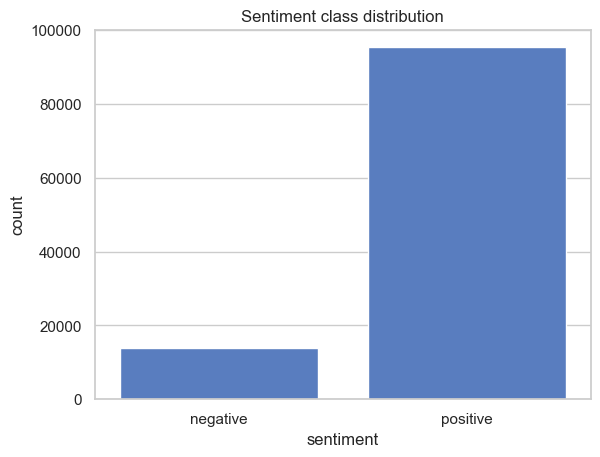

In [17]:
# Ensure sentiment labels are exactly positive/negative
print('Unique sentiment tags before encoding:', data['sentiment'].unique())

# If labels are in another format (e.g., 0/1), map them explicitly
if set(data['sentiment'].unique()) <= {0,1}:
    mapping = {0:'negative', 1:'positive'}
    data['sentiment'] = data['sentiment'].map(mapping)

print('Unique sentiment tags after normalization:', data['sentiment'].unique())

# Remove empty rows
data = data[data['cleaned_text'].str.strip() != '']
print('Shape after cleaning:', data.shape)

sns.countplot(x='sentiment', data=data)
plt.title('Sentiment class distribution')
plt.show()

## 6. Data Splitting

In [18]:
X = data['cleaned_text']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True))

Train shape: (87312,) Test shape: (21828,)

Train class balance:
sentiment
positive    0.873729
negative    0.126271
Name: proportion, dtype: float64

Test class balance:
sentiment
positive    0.87374
negative    0.12626
Name: proportion, dtype: float64


## 7. Modeling
- Models: Naive Bayes, Logistic Regression and SVM
- Using TF-IDF based vectorization

### Baseline Models

In [19]:
# Baseline Model pipelines
baseline_pipelines = {
    'LR_baseline': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=100)),
        ('clf', LogisticRegression(max_iter=20, C=0.01))
    ]),
    'NB_baseline': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=100)),
        ('clf', MultinomialNB(alpha=2))
    ]),
    'SVM_baseline': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=100)),
        ('clf', LinearSVC(C=0.001))
    ])
}

=== LR_baseline ===
Accuracy: 0.8851
Precision: 0.8844
Recall: 0.9991
F1 Score: 0.9382
Classification Report:
               precision    recall  f1-score   support

    negative     0.9364    0.0962    0.1744      2756
    positive     0.8844    0.9991    0.9382     19072

    accuracy                         0.8851     21828
   macro avg     0.9104    0.5476    0.5563     21828
weighted avg     0.8909    0.8851    0.8418     21828



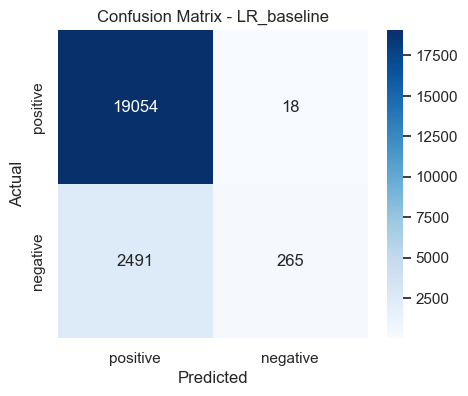

=== NB_baseline ===
Accuracy: 0.8824
Precision: 0.8818
Recall: 0.9993
F1 Score: 0.9369
Classification Report:
               precision    recall  f1-score   support

    negative     0.9352    0.0733    0.1359      2756
    positive     0.8818    0.9993    0.9369     19072

    accuracy                         0.8824     21828
   macro avg     0.9085    0.5363    0.5364     21828
weighted avg     0.8886    0.8824    0.8358     21828



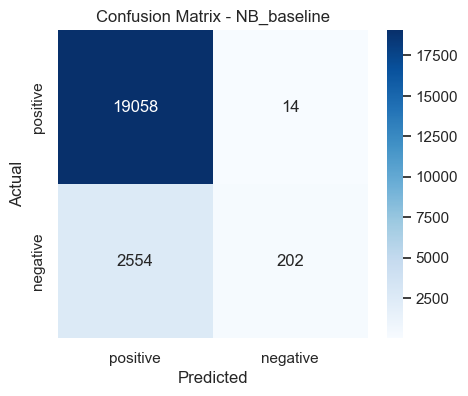

=== SVM_baseline ===
Accuracy: 0.8849
Precision: 0.8843
Recall: 0.9989
F1 Score: 0.9381
Classification Report:
               precision    recall  f1-score   support

    negative     0.9263    0.0958    0.1736      2756
    positive     0.8843    0.9989    0.9381     19072

    accuracy                         0.8849     21828
   macro avg     0.9053    0.5473    0.5559     21828
weighted avg     0.8896    0.8849    0.8416     21828



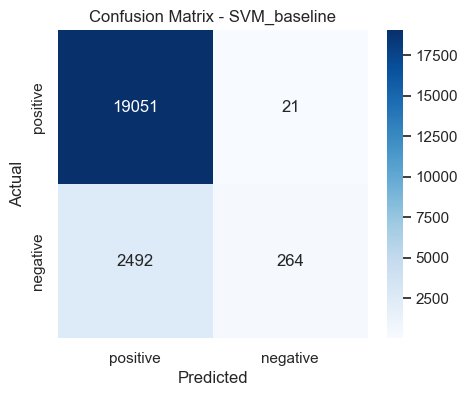

In [20]:
results = {}
for name, pipe in baseline_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')
    results[name] = {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'y_pred':y_pred}
    print(f'=== {name} ===')
    print('Accuracy:', round(acc,4))
    print('Precision:', round(prec,4))
    print('Recall:', round(rec,4))
    print('F1 Score:', round(f1,4))
    print('Classification Report:\n', classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred, labels=['positive','negative'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative'], yticklabels=['positive','negative'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Tuned Models

In [21]:
# Self-Tuned Model pipeline definitions
tuned_pipelines = {
    'LR_Good': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.9, min_df=2)),
        ('clf', LogisticRegression(max_iter=400, solver='liblinear'))
    ]),
    'NB_Good': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.9, min_df=2)),
        ('clf', MultinomialNB())
    ]),
    'SVM_Good': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_df=0.9, min_df=2)),
        ('clf', LinearSVC(C=1.0))
    ])
}

=== LR_Good ===
Accuracy: 0.9513
Precision: 0.9514
Recall: 0.9951
F1 Score: 0.9728
Classification Report:
               precision    recall  f1-score   support

    negative     0.9505    0.6484    0.7709      2756
    positive     0.9514    0.9951    0.9728     19072

    accuracy                         0.9513     21828
   macro avg     0.9510    0.8218    0.8719     21828
weighted avg     0.9513    0.9513    0.9473     21828



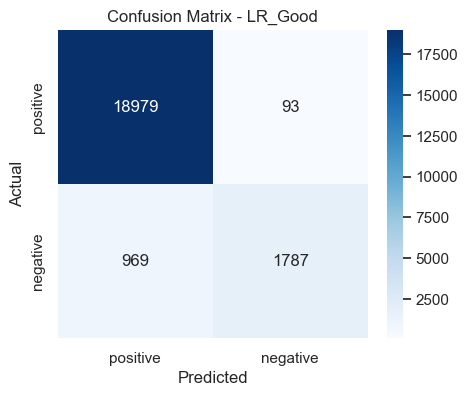

=== NB_Good ===
Accuracy: 0.8986
Precision: 0.8977
Recall: 0.9977
F1 Score: 0.945
Classification Report:
               precision    recall  f1-score   support

    negative     0.9303    0.2130    0.3466      2756
    positive     0.8977    0.9977    0.9450     19072

    accuracy                         0.8986     21828
   macro avg     0.9140    0.6053    0.6458     21828
weighted avg     0.9018    0.8986    0.8695     21828



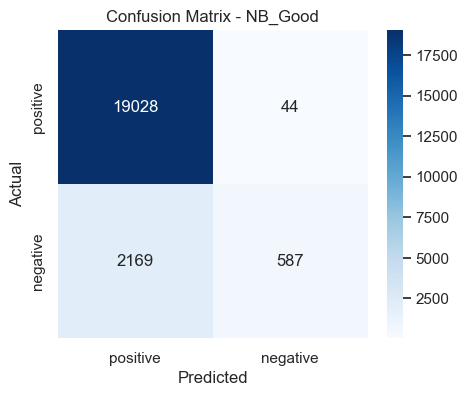

=== SVM_Good ===
Accuracy: 0.9654
Precision: 0.9716
Recall: 0.9894
F1 Score: 0.9804
Classification Report:
               precision    recall  f1-score   support

    negative     0.9157    0.7997    0.8538      2756
    positive     0.9716    0.9894    0.9804     19072

    accuracy                         0.9654     21828
   macro avg     0.9436    0.8945    0.9171     21828
weighted avg     0.9645    0.9654    0.9644     21828



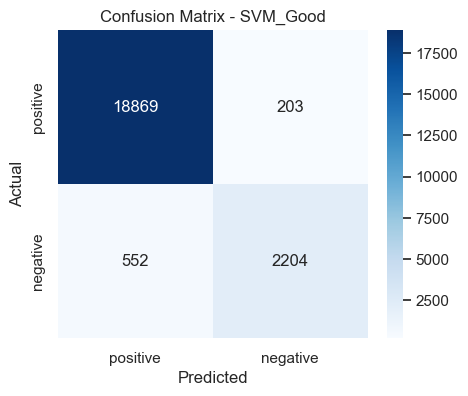

In [22]:
for name, pipe in tuned_pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='positive')
    rec = recall_score(y_test, y_pred, pos_label='positive')
    f1 = f1_score(y_test, y_pred, pos_label='positive')
    results[name] = {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'y_pred':y_pred}
    print(f'=== {name} ===')
    print('Accuracy:', round(acc,4))
    print('Precision:', round(prec,4))
    print('Recall:', round(rec,4))
    print('F1 Score:', round(f1,4))
    print('Classification Report:\n', classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred, labels=['positive','negative'])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','negative'], yticklabels=['positive','negative'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

### Hyperparameter Tuning on Best Performing Algorithm

In [23]:
param_grid_svm = {
    'tfidf__max_features': [1000, 3000, 5000],
    'clf__C': [0.1, 1, 10]
}

grid_svm = GridSearchCV(
    Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', LinearSVC())
    ]),
    param_grid_svm,
    cv=3,
    scoring='accuracy'
)

grid_svm.fit(X_train, y_train)

print("Best Params:", grid_svm.best_params_)
print("Best Score:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
y_pred_svm_best = best_svm.predict(X_test)
acc_svm_best = accuracy_score(y_test, y_pred_svm_best)
prec_svm_best = precision_score(y_test, y_pred, pos_label='positive')
rec_svm_best = recall_score(y_test, y_pred, pos_label='positive')
f1_svm_best = f1_score(y_test, y_pred, pos_label='positive')

print("Tuned SVM Accuracy:", acc_svm_best)

results["Tuned SVM Model"] = {'accuracy':acc_svm_best, 'precision':prec_svm_best, 'recall':rec_svm_best, 'f1':f1_svm_best, 'y_pred':y_pred_svm_best}

Best Params: {'clf__C': 1, 'tfidf__max_features': 5000}
Best Score: 0.9787428990287704
Tuned SVM Accuracy: 0.9812167857797325


In [24]:
# Compare metrics in tabular form
results_summary = pd.DataFrame(results).T[['accuracy','precision','recall','f1']]
results_summary

,accuracy,precision,recall,f1
LR_baseline,0.885056,0.884382,0.999056,0.938228
NB_baseline,0.882353,0.881825,0.999266,0.936879
SVM_baseline,0.884873,0.884324,0.998899,0.938126
LR_Good,0.951347,0.951424,0.995124,0.972783
NB_Good,0.898616,0.897674,0.997693,0.945045
SVM_Good,0.965411,0.971577,0.989356,0.980386
Tuned SVM Model,0.981217,0.971577,0.989356,0.980386


## 8. Model Interpretation and conclusion
- Compare models and choose the best performing one.
- Note typical limitations and next steps (tuning, more features, data augmentation, cross-validation).

In [25]:
best_model = results_summary['f1'].idxmax()
print('Best model by F1 score:', best_model)

Best model by F1 score: SVM_Good


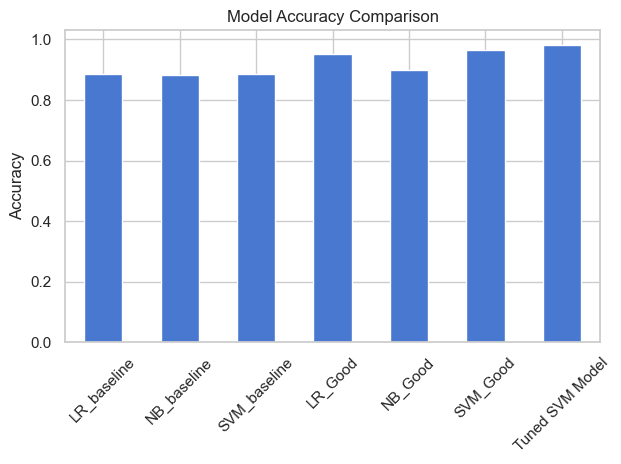

In [26]:
# 1. Accuracy Comparison
plt.figure()
results_summary['accuracy'].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

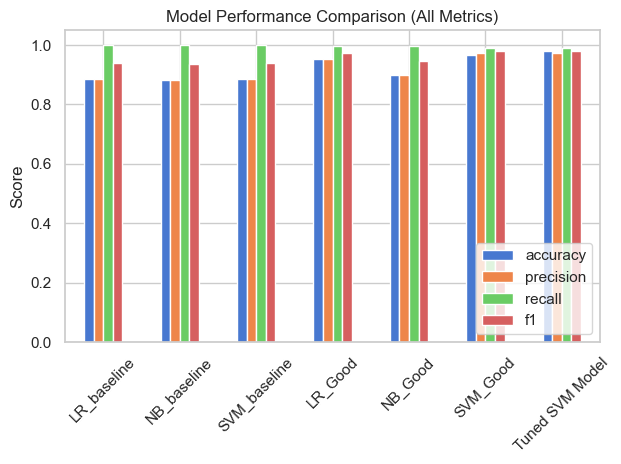

In [27]:
# 2. Multi-Metric Comparison
plt.figure()
results_summary.plot(kind='bar')
plt.title("Model Performance Comparison (All Metrics)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Top positive features: ['successful' 'excellent' 'love' 'interesting' 'advanced' 'available'
 'right' 'latest' 'important' 'free' 'better' 'new' 'good' 'best' 'great']
Top negative features: ['artificial' 'bad' 'wrong' 'common' 'game' 'small' 'base' 'complex'
 'mean' 'fake' 'secret' 'hard' 'worst' 'raw' 'random']


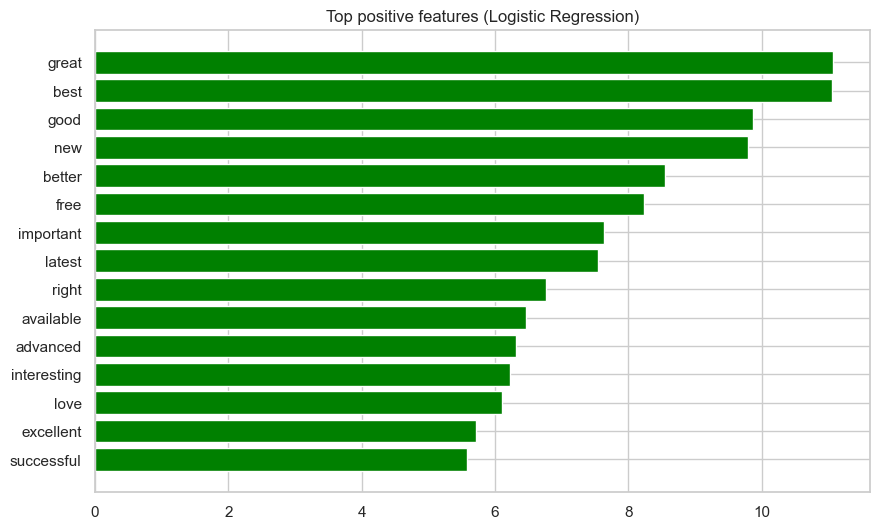

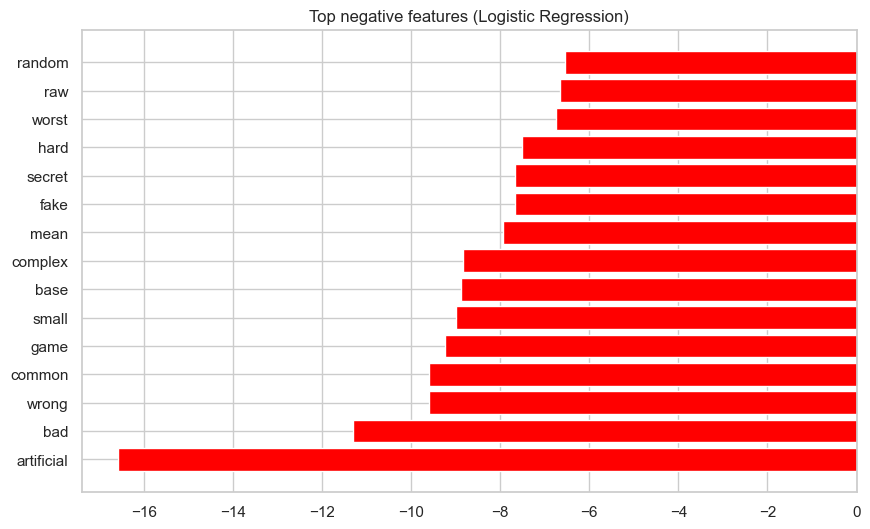

In [28]:
# plot top features from best logistic regression
lr = tuned_pipelines['LR_Good']
vect = lr.named_steps['tfidf']
clf = lr.named_steps['clf']
feature_names = np.array(vect.get_feature_names_out())
top_pos = np.argsort(clf.coef_[0])[-15:]
top_neg = np.argsort(clf.coef_[0])[:15]
print('Top positive features:', feature_names[top_pos])
print('Top negative features:', feature_names[top_neg])

plt.figure(figsize=(10,6))
plt.barh(feature_names[top_pos], clf.coef_[0][top_pos], color='green')
plt.title('Top positive features (Logistic Regression)')
plt.show()

plt.figure(figsize=(10,6))
plt.barh(feature_names[top_neg], clf.coef_[0][top_neg], color='red')
plt.title('Top negative features (Logistic Regression)')
plt.show()

In [29]:
import pickle

# Save best model pipeline
final_model = tuned_pipelines[best_model]

with open("../sentiment_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved as sentiment_model.pkl in root directory")

Model saved as sentiment_model.pkl in root directory
